In [ ]:
# Task 6: RGB Image Creation (Sentinel-2)

# Objective:
# Create true-color RGB images by stacking Sentinel-2 bands
# (B04, B03, B02) for data preprocessing.


In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [4]:
b02_path = r"A:\Main Project\Satellite_SR\data\City1_T43PGQ\S2B_MSIL2A_20251213T051119_N0511_R019_T43PGQ_20251213T071206\S2B_MSIL2A_20251213T051119_N0511_R019_T43PGQ_20251213T071206.SAFE\GRANULE\L2A_T43PGQ_A045805_20251213T052354\IMG_DATA\R10m\T43PGQ_20251213T051119_B02_10m.jp2"
b03_path = r"A:\Main Project\Satellite_SR\data\City1_T43PGQ\S2B_MSIL2A_20251213T051119_N0511_R019_T43PGQ_20251213T071206\S2B_MSIL2A_20251213T051119_N0511_R019_T43PGQ_20251213T071206.SAFE\GRANULE\L2A_T43PGQ_A045805_20251213T052354\IMG_DATA\R10m\T43PGQ_20251213T051119_B03_10m.jp2"
b04_path = r"A:\Main Project\Satellite_SR\data\City1_T43PGQ\S2B_MSIL2A_20251213T051119_N0511_R019_T43PGQ_20251213T071206\S2B_MSIL2A_20251213T051119_N0511_R019_T43PGQ_20251213T071206.SAFE\GRANULE\L2A_T43PGQ_A045805_20251213T052354\IMG_DATA\R10m\T43PGQ_20251213T051119_B04_10m.jp2"

In [5]:
with rasterio.open(b02_path) as src:
    b02 = src.read(1)

with rasterio.open(b03_path) as src:
    b03 = src.read(1)

with rasterio.open(b04_path) as src:
    b04 = src.read(1)

print(b02.shape, b03.shape, b04.shape)


MemoryError: Unable to allocate 230. MiB for an array with shape (1, 10980, 10980) and data type uint16

In [4]:
rgb = np.stack([b04, b03, b02], axis=-1)
print("RGB shape:", rgb.shape)
print("RGB dtype:", rgb.dtype)


RGB shape: (10980, 10980, 3)
RGB dtype: uint16


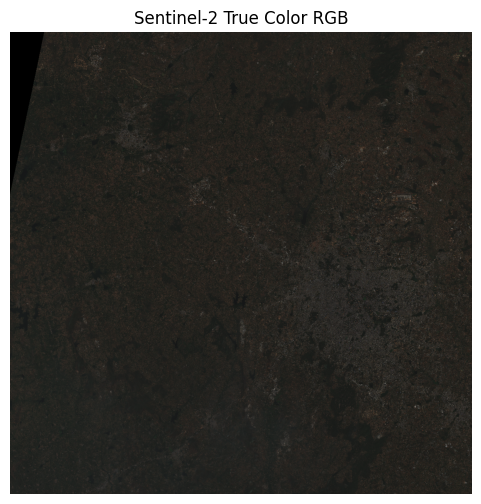

In [5]:
rgb_display = rgb[::10, ::10, :].astype("float32")
rgb_display = rgb_display / rgb_display.max()

plt.figure(figsize=(6, 6))
plt.imshow(rgb_display)
plt.title("Sentinel-2 True Color RGB")
plt.axis("off")
plt.show()


In [6]:
# Task 7: RGB Normalization

# Objective:
# Normalize the RGB image created from Sentinel-2 bands so that
# pixel values are scaled to a range suitable for deep learning models.


In [7]:
# Convert RGB to float32 for safe numerical operations
rgb_float = rgb.astype("float32")

print("Before normalization:")
print("Min:", rgb_float.min(), "Max:", rgb_float.max())


Before normalization:
Min: 0.0 Max: 19216.0


In [10]:
# Downsample first to reduce memory
rgb_small = rgb[::10, ::10, :].astype("float32")

# Normalize downsampled RGB for display only
rgb_norm_display = rgb_small / rgb_small.max()

print("Display RGB min:", rgb_norm_display.min())
print("Display RGB max:", rgb_norm_display.max())


Display RGB min: 0.0
Display RGB max: 1.0


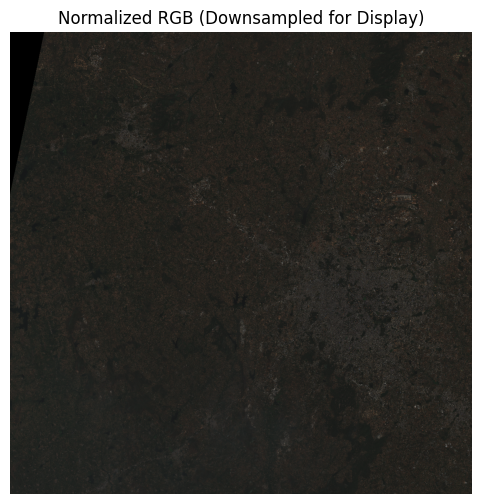

In [11]:
plt.figure(figsize=(6, 6))
plt.imshow(rgb_norm_display)
plt.title("Normalized RGB (Downsampled for Display)")
plt.axis("off")
plt.show()


In [12]:
# Task 8: High-Resolution Patch Extraction

# Objective:
# Extract fixed-size high-resolution (HR) patches from
# the normalized Sentinel-2 RGB image to prepare training data
# for super-resolution.


In [16]:
def extract_patches(image, patch_size=96, stride=96):
    patches = []
    h, w, c = image.shape

    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            patch = image[i:i+patch_size, j:j+patch_size, :]
            patches.append(patch)

    return patches


In [14]:
# Use normalized, downsampled RGB from Task 7
rgb_for_patches = rgb_norm_display  # shape is manageable

print("RGB used for patches:", rgb_for_patches.shape)


RGB used for patches: (1098, 1098, 3)


In [15]:
patches = extract_patches(rgb_for_patches, patch_size=96, stride=96)

print("Number of HR patches extracted:", len(patches))
print("Shape of one patch:", patches[0].shape)


Number of HR patches extracted: 121
Shape of one patch: (96, 96, 3)


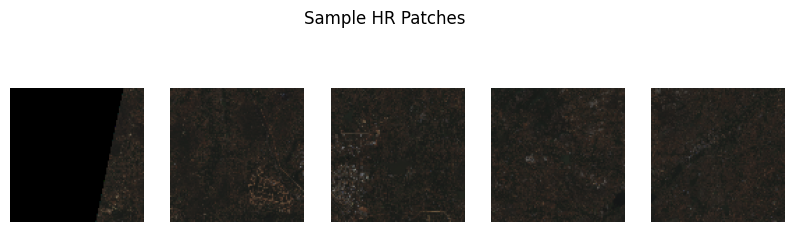

In [17]:
plt.figure(figsize=(10, 3))

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(patches[i])
    plt.axis("off")

plt.suptitle("Sample HR Patches")
plt.show()


In [18]:
# Task 9: LR–HR Patch Pair Generation

# Objective:
# Generate low-resolution (LR) patches from high-resolution (HR)
# patches to prepare supervised training data for super-resolution.


In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [21]:
def generate_lr_patch(hr_patch, scale=2):
    h, w, c = hr_patch.shape

    # Downsample (HR → LR)
    lr = cv2.resize(
        hr_patch,
        (w // scale, h // scale),
        interpolation=cv2.INTER_AREA
    )

    # Upsample back to HR size
    lr_up = cv2.resize(
        lr,
        (w, h),
        interpolation=cv2.INTER_CUBIC
    )

    return lr_up


In [22]:
hr_patches = patches  # from Task 8

lr_patches = [generate_lr_patch(patch, scale=2) for patch in hr_patches]

print("HR patch shape:", hr_patches[0].shape)
print("LR patch shape:", lr_patches[0].shape)


HR patch shape: (96, 96, 3)
LR patch shape: (96, 96, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.025559826..0.33620518].


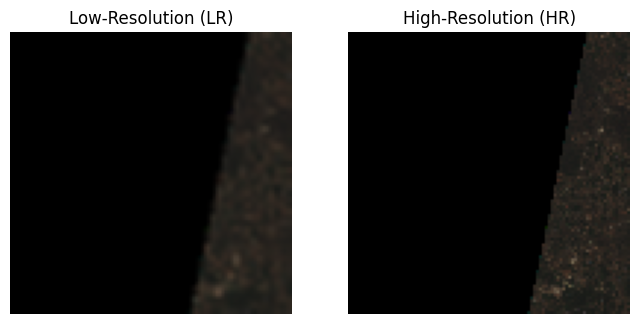

In [23]:
idx = 0  # sample index

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(lr_patches[idx])
plt.title("Low-Resolution (LR)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hr_patches[idx])
plt.title("High-Resolution (HR)")
plt.axis("off")

plt.show()
